In [6]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


1.Dataset understanding

In [7]:
import pandas as pd
df=pd.read_csv('C:\\Users\\HP 640 G5\\Desktop\\videogamesales_predicton\\data\\raw\\vgsales.csv')
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [8]:
#dataset dimensions
df.shape

(16598, 11)

In [9]:
#dataset columns
df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='str')

In [10]:
#dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


In [11]:
#statistical summary of the dataset
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [12]:
#missing values in the dataset
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [13]:
#duplicate analysis
df.duplicated().sum()

np.int64(0)

2.Data cleaning

In [14]:
#handling missing year values by deleting the rows with missing year values
df.dropna(subset=['Year'], inplace=True)
df['Year'].isnull().sum()

np.int64(0)

In [15]:
#handling missing publisher values by replacing with 'Unknown' publisher values
df['Publisher']=df['Publisher'].fillna('Unknown')
df['Publisher'].isnull().sum()

np.int64(0)

In [16]:
#verifying the changes made to the dataset
df.isnull().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [17]:
#checking year values
print("min year:",df['Year'].min())
print("max year:",df['Year'].max())
df['Year'].sort_values().unique()

min year: 1980.0
max year: 2020.0


array([1980., 1981., 1982., 1983., 1984., 1985., 1986., 1987., 1988.,
       1989., 1990., 1991., 1992., 1993., 1994., 1995., 1996., 1997.,
       1998., 1999., 2000., 2001., 2002., 2003., 2004., 2005., 2006.,
       2007., 2008., 2009., 2010., 2011., 2012., 2013., 2014., 2015.,
       2016., 2017., 2020.])

In [18]:
df.dtypes

Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [19]:
#checking the size of the dataset after cleaning the dataset
df.shape

(16327, 11)

In [ ]:
import os
os.makedirs("C:\\Users\\HP 640 G5\\Desktop\\videogamesales_predicton\\data\\processed",exist_ok=True)
df.to_csv("C:\\Users\\HP 640 G5\\Desktop\\videogamesales_predicton\\data\\processed\\vgsales_cleaned.csv",index=False)

3.Exploratory data analysis(eda)

In [20]:
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

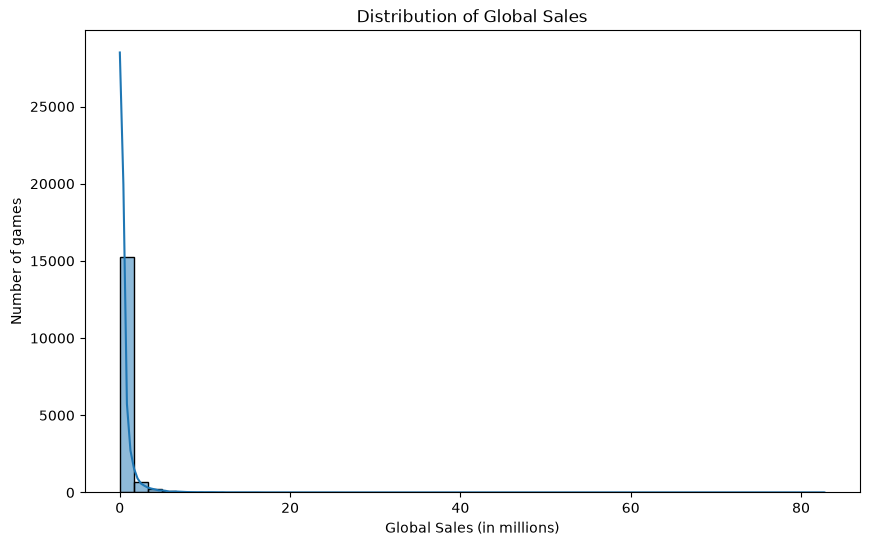

In [22]:
#distribution of global sales
plt.figure(figsize=(10, 6))
sns.histplot( 
    x=df['Global_Sales'], 
    bins=50, 
    kde=True
)
plt.title('Distribution of Global Sales')
plt.xlabel('Global Sales (in millions)')
plt.ylabel('Number of games')
plt.show()

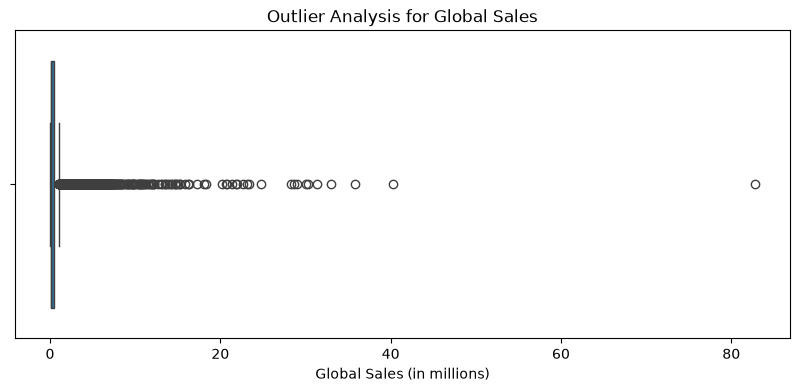

In [23]:
#outlier analysis for global sales
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Global_Sales'])
plt.title('Outlier Analysis for Global Sales')
plt.xlabel('Global Sales (in millions)')
plt.show()

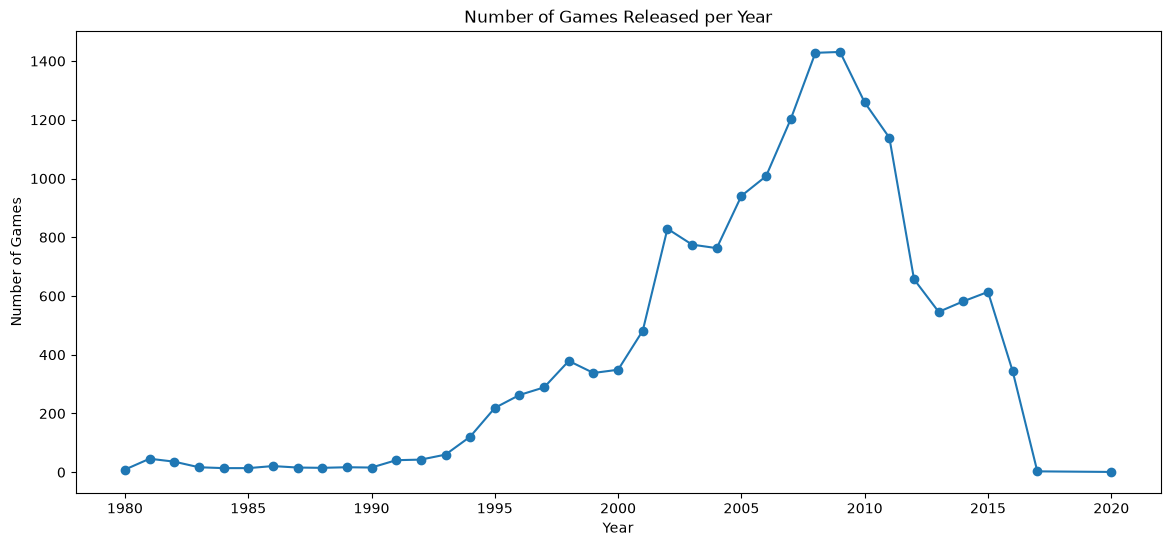

In [24]:
#Number of games released per year
yearly_counts = df['Year'].value_counts().sort_index()
plt.figure(figsize=(14, 6))
plt.plot(yearly_counts.index, yearly_counts.values, marker='o')
plt.title('Number of Games Released per Year')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.show()

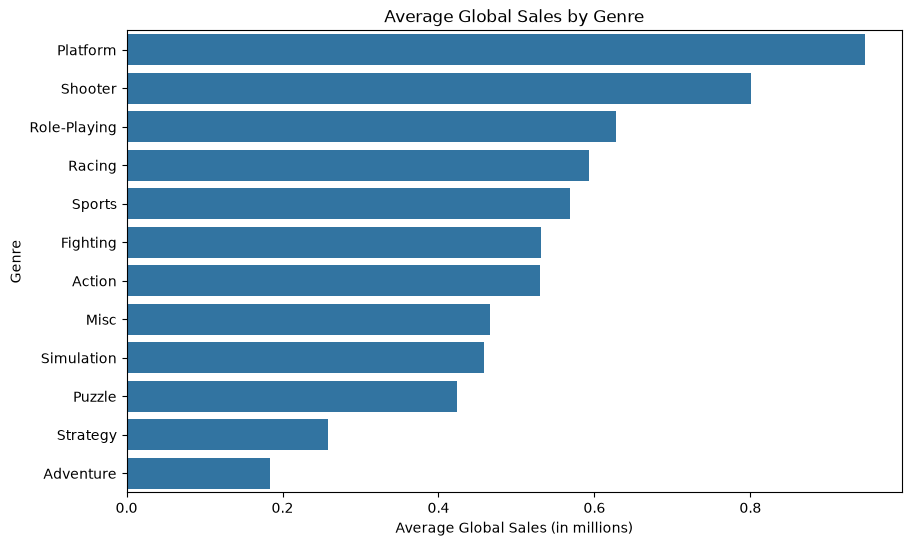

In [25]:
#average global sales by genre
genre_sales = df.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=genre_sales.values,
    y=genre_sales.index
)
plt.title('Average Global Sales by Genre')
plt.xlabel('Average Global Sales (in millions)')
plt.ylabel('Genre')
plt.show()


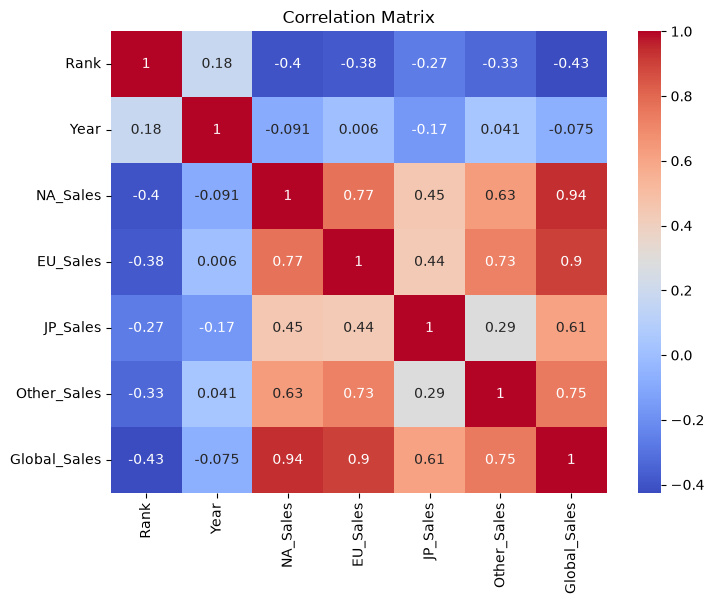

In [26]:
#correlation analysis between global sales and other sales columns
plt.figure(figsize=(8, 6))
correlation= df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

4.Feature engineering and Feature selection

In [27]:
#feature selection
features = ['Platform', 'Year', 'Genre', 'Publisher']
x = df[features]
y = df['Global_Sales']

In [28]:
#selected features
x.head()

,Platform,Year,Genre,Publisher
0,Wii,2006.0,Sports,Nintendo
1,NES,1985.0,Platform,Nintendo
2,Wii,2008.0,Racing,Nintendo
3,Wii,2009.0,Sports,Nintendo
4,GB,1996.0,Role-Playing,Nintendo


In [29]:
#target variable
y.head()

0    82.74
1    40.24
2    35.82
3    33.00
4    31.37
Name: Global_Sales, dtype: float64

In [30]:
#checking feature types
x.dtypes

Platform         str
Year         float64
Genre            str
Publisher        str
dtype: object

In [31]:
#cardinality analysis
print("Platform cardinality:", x['Platform'].nunique())
print("Genre cardinality:", x['Genre'].nunique())
print("Publisher cardinality:", x['Publisher'].nunique())

Platform cardinality: 31
Genre cardinality: 12
Publisher cardinality: 576


In [32]:
#verify x and y shapes
print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (16327, 4)
Target shape: (16327,)


5.Encoding & Train-Test Split

In [33]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [35]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [37]:
#checking the shape of the training and testing sets
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training targets:", y_train.shape)
print("Testing targets:", y_test.shape)


Training features: (13061, 4)
Testing features: (3266, 4)
Training targets: (13061,)
Testing targets: (3266,)


In [38]:
#one hot encoding for categorical features
categorical_features = ['Platform', 'Genre', 'Publisher']
numerical_features = ['Year']
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('numerical', StandardScaler(), numerical_features)
    ]
)   

In [39]:
#fitting the preprocessor on the training data
x_train_encoded = preprocessor.fit_transform(X_train)
x_test_encoded = preprocessor.transform(X_test)

In [40]:
#checking the number of features created after one hot encoding
print("Number of features before encoding:", x.shape[1])
print("Number of features after one hot encoding:", x_train_encoded.shape[1])   

Number of features before encoding: 4
Number of features after one hot encoding: 574


6.Building multiple Machine Learning models

In [41]:
#importing machine learning models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline


In [42]:
#creating a preprocessing pipeline for the models
categorical_features = ['Platform', 'Genre', 'Publisher']
numerical_features = ['Year']

preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('numerical', StandardScaler(), numerical_features)
    ]
)

In [43]:
#linear regression model pipeline
linear_model = Pipeline([
    ('preprocessor', preprocessing_pipeline),
    ('regressor', LinearRegression())
])

In [44]:
#ridge regression model pipeline
ridge_model = Pipeline([
    ('preprocessor', preprocessing_pipeline),
    ('model', Ridge(alpha=1.0))
])

In [45]:
#random forest regression model pipeline
random_forest_model = Pipeline([
    ('preprocessor', preprocessing_pipeline),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [46]:
#gradient boosting regression model pipeline
gradient_boosting_model = Pipeline([
    ('preprocessor', preprocessing_pipeline),
    ('model', GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42))
])

In [47]:
#model collection
models = {
    'Linear Regression': linear_model,
    'Ridge Regression': ridge_model,
    'Random Forest Regression': random_forest_model,
    'Gradient Boosting Regression': gradient_boosting_model
}
models.keys()

dict_keys(['Linear Regression', 'Ridge Regression', 'Random Forest Regression', 'Gradient Boosting Regression'])

In [48]:
#training the models
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

print("All models trained successfully.")

Training Linear Regression...
Training Ridge Regression...
Training Random Forest Regression...
Training Gradient Boosting Regression...
All models trained successfully.


In [49]:
#generating predictions
predictions = {}
for name, model in models.items():
    predictions[name] = model.predict(X_test)
print("Predictions generated for all models.")

Predictions generated for all models.


In [50]:
for name, preds in predictions.items():
    print(f"{name} Predictions: {preds[:5]}") 

Linear Regression Predictions: [0.40574037 0.22041923 1.038902   0.45714112 0.50240393]
Ridge Regression Predictions: [0.40584514 0.22064259 1.03472992 0.45482595 0.50066024]
Random Forest Regression Predictions: [0.72951667 0.22863333 0.15457833 0.642415   0.24132   ]
Gradient Boosting Regression Predictions: [0.42039989 0.26197942 0.64462926 0.45374846 0.24156744]


7.Model Evaluation and Comparison

In [51]:
#importing evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

In [52]:
#calculating model performance
results=[]
for name, preds in predictions.items():
    mse = mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    results.append({
        'Model': name, 
        'MSE': mse, 
        'MAE': mae,
        'RMSE': rmse, 
        'R2': r2
    })
results_df = pd.DataFrame(results)
results_df

,Model,MSE,MAE,RMSE,R2
0,Linear Regression,3.892582,0.566167,1.972963,0.088930
1,Ridge Regression,3.890813,0.563664,1.972514,0.089344
2,Random Forest Regression,4.192899,0.535835,2.047657,0.018640
3,Gradient Boosting Regression,3.838814,0.524417,1.959289,0.101515


In [53]:
#sort models by R2 score in descending order
results_df = results_df.sort_values(by='R2', ascending=False)

In [54]:
#finding the best model
best_model = results_df.loc[
    results_df['R2'].idxmax(),
    'Model'
]
best_model

'Gradient Boosting Regression'

In [55]:
#finding the best RMSE
best_rmse_model = results_df.loc[
    results_df['RMSE'].idxmin(),
    'Model'
]
best_rmse_model

'Gradient Boosting Regression'

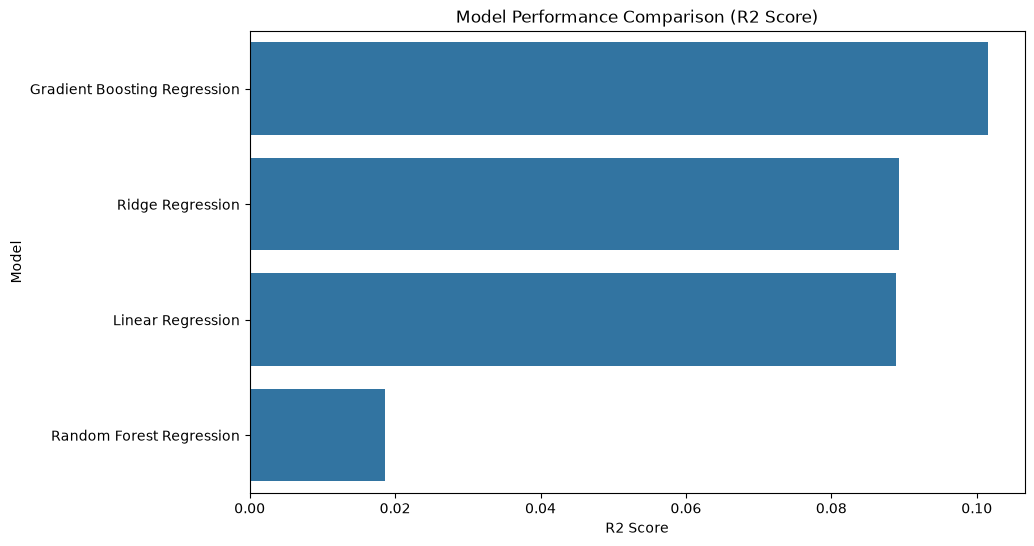

In [56]:
#model performance comparison
plt.figure(figsize=(10, 6))

sns.barplot(
    x='R2', 
    y='Model', 
    data=results_df
)
plt.title('Model Performance Comparison (R2 Score)')
plt.xlabel('R2 Score')
plt.ylabel('Model')

plt.show()

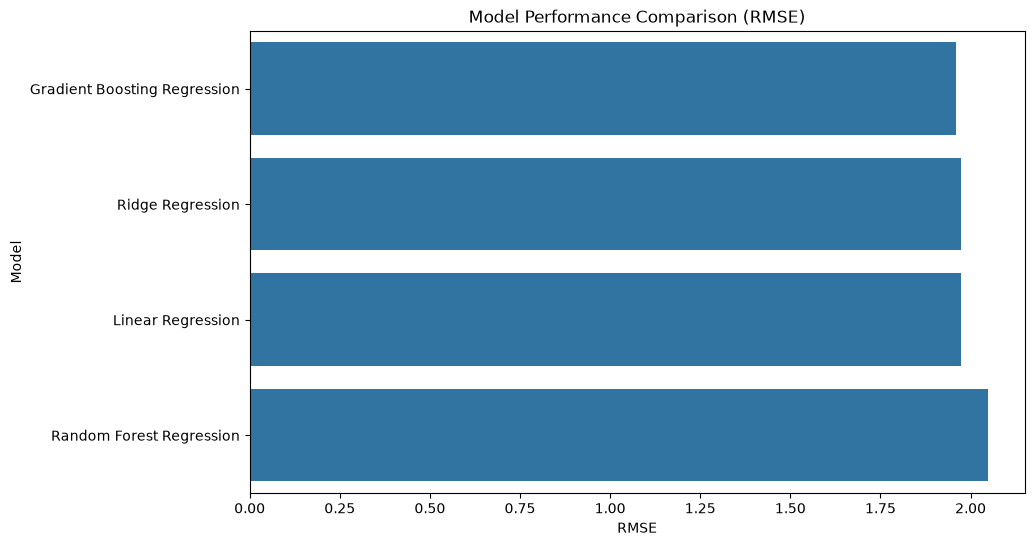

In [57]:
#RMSE comparison
plt.figure(figsize=(10, 6))
sns.barplot(
    x='RMSE', 
    y='Model', 
    data=results_df
)
plt.title('Model Performance Comparison (RMSE)')
plt.xlabel('RMSE')
plt.ylabel('Model')

plt.show()

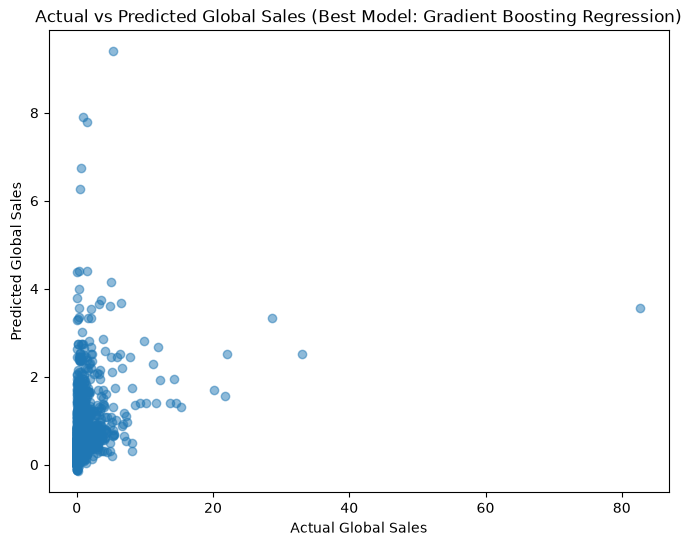

In [58]:
#actual glopal sales vs predicted global sales
# Keep best_model as the model name used as the key in predictions
best_model = results_df.loc[results_df['R2'].idxmax(), 'Model']
best_predictions = predictions[best_model] 
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_predictions, alpha=0.5)
plt.xlabel('Actual Global Sales')
plt.ylabel('Predicted Global Sales')
plt.title(f'Actual vs Predicted Global Sales (Best Model: {best_model})')
plt.show()

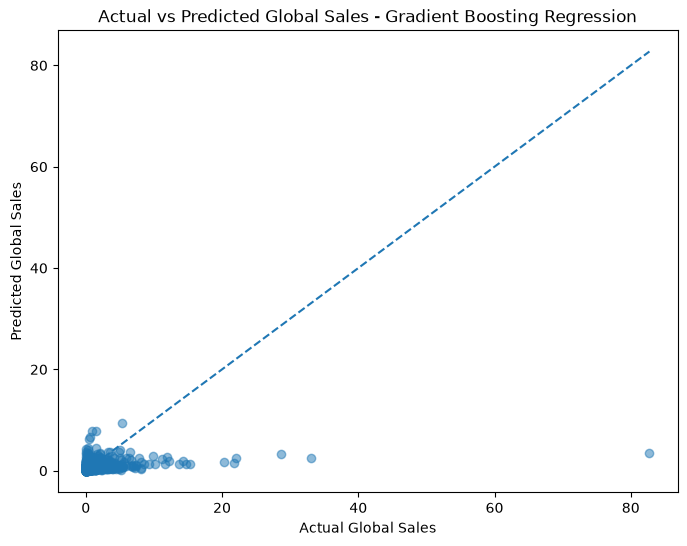

In [59]:
#adding a perfect prediction line
plt.figure(figsize=(8, 6))

plt.scatter(y_test, best_predictions, alpha=0.5)

max_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle='--'
)

plt.xlabel('Actual Global Sales')
plt.ylabel('Predicted Global Sales')
plt.title(f'Actual vs Predicted Global Sales - {best_model}')

plt.show()

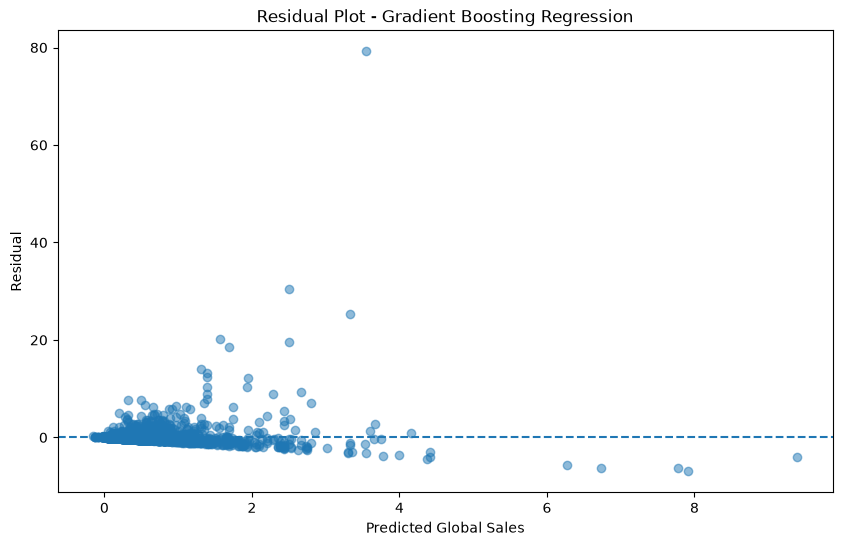

In [60]:
#residual analysis
residuals = y_test - best_predictions

plt.figure(figsize=(10, 6))

plt.scatter(best_predictions, residuals, alpha=0.5)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Global Sales')
plt.ylabel('Residual')
plt.title(f'Residual Plot - {best_model}')

plt.show()

In [61]:
#model comparison
results_df.sort_values(
    by='R2',
    ascending=False
).reset_index(drop=True)

,Model,MSE,MAE,RMSE,R2
0,Gradient Boosting Regression,3.838814,0.524417,1.959289,0.101515
1,Ridge Regression,3.890813,0.563664,1.972514,0.089344
2,Linear Regression,3.892582,0.566167,1.972963,0.088930
3,Random Forest Regression,4.192899,0.535835,2.047657,0.018640


In [97]:
import os
os.makedirs("C:\\Users\\HP 640 G5\\Desktop\\videogamesales_predicton\\outputs", exist_ok=True) 
results_df.to_csv("C:\\Users\\HP 640 G5\\Desktop\\videogamesales_predicton\\outputs\\model_performance.csv", index=False)


CONCLUSION FOR PART 7
Four regression models were evaluated using MSE, MAE, RMSE, and R² Score.

Gradient Boosting Regression achieved the best overall performance, with the lowest MSE, MAE, and RMSE and the highest R² Score.

Therefore, Gradient Boosting Regression is selected as the current best-performing baseline model.

However, its R² score of approximately 0.1015 indicates that the selected features do not explain all the variation in Global Sales. Hyperparameter tuning will therefore be performed to determine whether the model's performance can be improved.

8.Final Best Model Selection

In [71]:
#selecting the best model based on R2 score
best_model_name = results_df.loc[
    results_df['R2'].idxmax(),
    'Model'
]

In [73]:
#final model
final_model = models[best_model_name]
print(f"Best Model: {best_model_name}")

Best Model: Gradient Boosting Regression


In [74]:
#training the final model on the entire training dataset
final_model.fit(X_train, y_train)
print("Final model trained successfully.")

Final model trained successfully.


In [75]:
#evaluating the final model on the test dataset
final_predictions = final_model.predict(X_test)
final_model.predict(X_test)

final_mse = mean_squared_error(y_test, final_predictions)
final_mae = mean_absolute_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, final_predictions)

print(f"Final Model Performance:")
print(f"Mean Squared Error: {final_mse}")
print(f"Mean Absolute Error: {final_mae}")
print(f"Root Mean Squared Error: {final_rmse}")
print(f"R-squared: {final_r2}")


Final Model Performance:
Mean Squared Error: 3.8388140546805993
Mean Absolute Error: 0.5244170711324969
Root Mean Squared Error: 1.9592891707659181
R-squared: 0.1015147944616056


In [81]:
import joblib
import os

# Save the final model
os.makedirs("models", exist_ok=True)
joblib.dump(final_model, "C:\\Users\\HP 640 G5\\Desktop\\videogamesales_predicton\\models\\final_model.pkl")
print("Final model saved as 'models/final_model.pkl'.")

Final model saved as 'models/final_model.pkl'.


In [82]:
#verifying the saved model by loading it and making predictions
loaded_model = joblib.load("C:\\Users\\HP 640 G5\\Desktop\\videogamesales_predicton\\models\\final_model.pkl")
print("model loaded successfully.")
test_predictions = loaded_model.predict(X_test.iloc[:10])
print("sample prediction:", test_predictions[0])

model loaded successfully.
sample prediction: 0.4203998878489867


9.New/Unseen data prediction

In [83]:
#loading the saved model for future use
model=joblib.load("C:\\Users\\HP 640 G5\\Desktop\\videogamesales_predicton\\models\\final_model.pkl")
print("model loaded successfully.")

model loaded successfully.


In [84]:
#creating a new game data point for prediction
new_game = pd.DataFrame({
    'Platform': ['PS4'],
    'Year': [2020],
    'Genre': ['Action'],
    'Publisher': ['Electronic Arts']
})
new_game

,Platform,Year,Genre,Publisher
0,PS4,2020,Action,Electronic Arts


In [85]:
#making prediction for the new game data point
new_game_prediction = model.predict(new_game)
print("Predicted Global Sales for the new game:", new_game_prediction[0],"million units")

Predicted Global Sales for the new game: 1.7285022082512673 million units


In [88]:
#displaying prediction
predicted_sales = new_game_prediction[0]

print("VIDEO GAME SALES PREDICTION")

print("Platform:", new_game['Platform'].iloc[0])
print("Year:", new_game['Year'].iloc[0])
print("Genre:", new_game['Genre'].iloc[0])
print("Publisher:", new_game['Publisher'].iloc[0])

print(f"Predicted Global Sales: {predicted_sales:.2f} million units")


VIDEO GAME SALES PREDICTION
Platform: PS4
Year: 2020
Genre: Action
Publisher: Electronic Arts
Predicted Global Sales: 1.73 million units


In [94]:
#saving prediction to a CSV file
import os

os.makedirs('C:\\Users\\HP 640 G5\\Desktop\\videogamesales_predicton\\outputs', exist_ok=True)

prediction_result = new_game.copy()
prediction_result['Predicted_Global_Sales'] = predicted_sales

prediction_result.to_csv(
    'C:\\Users\\HP 640 G5\\Desktop\\videogamesales_predicton\\outputs\\new_game_prediction.csv',
    
)

print("Prediction saved successfully.")
print("Location: C:\\Users\\HP 640 G5\\Desktop\\videogamesales_predicton\\outputs\\new_game_prediction.csv")


Prediction saved successfully.
Location: C:\Users\HP 640 G5\Desktop\videogamesales_predicton\outputs\new_game_prediction.csv


In [95]:
#prediction interpretation
new_game_2=pd.DataFrame({
    'Platform': ['Xbox One'],
    'Year': [2021],
    'Genre': ['Adventure'],
    'Publisher': ['Microsoft Game Studios']
})
prediction_2 = model.predict(new_game_2)
print("new game:")
print(new_game_2)
print(f"Predicted Global Sales: {prediction_2[0]:.2f} million units")

new game:
   Platform  Year      Genre               Publisher
0  Xbox One  2021  Adventure  Microsoft Game Studios
Predicted Global Sales: 0.57 million units


10.Final Conclusion

In [99]:
print("Final Model: Gradient Boosting Regression")
print("Model saved at: ../models/final_model.pkl")

print("\nProject Status:")
print("✓ Data preprocessing completed")
print("✓ EDA completed")
print("✓ Multiple models trained")
print("✓ Models evaluated and compared")
print("✓ Best model selected")
print("✓ Final model saved")
print("✓ New/unseen data prediction completed")
print("\nEnd-to-End Machine Learning Project Completed Successfully!")

Final Model: Gradient Boosting Regression
Model saved at: ../models/final_model.pkl

Project Status:
✓ Data preprocessing completed
✓ EDA completed
✓ Multiple models trained
✓ Models evaluated and compared
✓ Best model selected
✓ Final model saved
✓ New/unseen data prediction completed

End-to-End Machine Learning Project Completed Successfully!
